# NLP Topic Modeling on Amazon Fine Food Reviews

## Project Overview
This notebook implements Natural Language Processing (NLP) techniques to analyze unstructured customer review texts from the Amazon Fine Food Reviews dataset. The objective is to preprocess the text data, convert the texts into numerical representations, and extract prevalent topics using topic modeling techniques.

The analysis is conducted using Python in Google Colab and follows a structured, step-by-step workflow.


## 1. Data Loading

In this step, the Amazon Fine Food Reviews dataset is loaded from Google Drive into the Python environment. The dataset contains customer review texts and associated metadata.


In [12]:
from google.colab import drive
drive.mount("/content/drive")

import pandas as pd

# ✅ Adjust this path if your folder name is different
PATH = "/content/drive/MyDrive/IU_NLP_Project/Reviews.csv"

df = pd.read_csv(PATH)
print("Loaded:", df.shape)
df.head(2)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded: (568454, 10)


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...


## 2. Data Preprocessing

The review text data are preprocessed to achieve "clean text". This includes lowercasing, removal of HTML artifacts, punctuation, special characters, and stopwords to reduce noise and improve topic interpretability.


In [13]:
import re

df_clean = df[["Score", "Text"]].copy()
df_clean.dropna(subset=["Text"], inplace=True)

df_clean["Text"] = df_clean["Text"].str.lower()

# Remove HTML line breaks token 'br' (very common in this dataset)
df_clean["Text"] = df_clean["Text"].apply(lambda x: re.sub(r"\bbr\b", " ", x))

# Remove punctuation/numbers/special chars
df_clean["Text"] = df_clean["Text"].apply(lambda x: re.sub(r"[^a-z\s]", " ", x))

# Remove extra spaces
df_clean["Text"] = df_clean["Text"].apply(lambda x: re.sub(r"\s+", " ", x).strip())

print("After basic clean:", df_clean.shape)
df_clean["Text"].head(2)


After basic clean: (568454, 2)


,Text
0,i have bought several of the vitality canned d...
1,product arrived labeled as jumbo salted peanut...


In [14]:
import nltk
from nltk.corpus import stopwords

nltk.download("stopwords")
stop_words = set(stopwords.words("english"))

df_clean["Text"] = df_clean["Text"].apply(
    lambda x: " ".join([w for w in x.split() if w not in stop_words])
)

df_clean["Text"].head(2)


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,Text
0,bought several vitality canned dog food produc...
1,product arrived labeled jumbo salted peanuts p...


## 3. Text Vectorization

To enable machine learning analysis, the cleaned texts are converted into numerical representations using Bag-of-Words (BoW) and Term Frequency–Inverse Document Frequency (TF-IDF).


In [15]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

sample_texts = df_clean["Text"].sample(20000, random_state=42)

bow_vectorizer = CountVectorizer(max_features=5000)
X_bow = bow_vectorizer.fit_transform(sample_texts)
print("BoW shape:", X_bow.shape)

tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf_vectorizer.fit_transform(sample_texts)
print("TF-IDF shape:", X_tfidf.shape)


BoW shape: (20000, 5000)
TF-IDF shape: (20000, 5000)


## 4. Topic Modeling

Topic modeling is applied to extract prevalent themes from the review texts. Latent Dirichlet Allocation (LDA) and Non-Negative Matrix Factorization (NMF) are used to identify latent topics.


In [16]:
from sklearn.decomposition import LatentDirichletAllocation, NMF

lda = LatentDirichletAllocation(n_components=8, random_state=42, learning_method="batch")
lda.fit(X_bow)

nmf = NMF(n_components=8, random_state=42)
W = nmf.fit_transform(X_tfidf)

feature_names_bow = bow_vectorizer.get_feature_names_out()
feature_names_tfidf = tfidf_vectorizer.get_feature_names_out()

print("Models trained.")


Models trained.


In [17]:
import numpy as np

def get_top_words(model, feature_names, topic_idx, n_top_words=12):
    topic = model.components_[topic_idx]
    top_idx = topic.argsort()[-n_top_words:][::-1]
    return [feature_names[i] for i in top_idx]


## 5. Topic Prevalence and Visualization

In this section, topic prevalence is computed to identify the most dominant topics across the dataset. The prevalence of each topic is visualized using bar charts to support interpretability.


Most prevalent LDA topic: 3
Top words: like, taste, flavor, good, chocolate, chips, one, snack, great, sweet, cookies, love


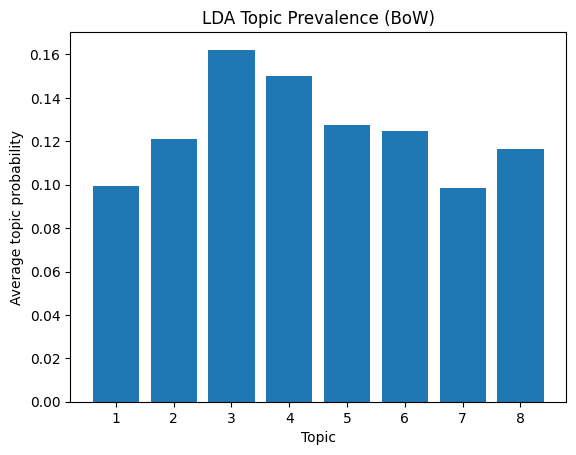

In [18]:
import matplotlib.pyplot as plt

doc_topic_lda = lda.transform(X_bow)
topic_prevalence_lda = doc_topic_lda.mean(axis=0)
top_topic_idx_lda = int(topic_prevalence_lda.argmax())

print("Most prevalent LDA topic:", top_topic_idx_lda + 1)
print("Top words:", ", ".join(get_top_words(lda, feature_names_bow, top_topic_idx_lda)))

plt.figure()
plt.bar(range(1, len(topic_prevalence_lda)+1), topic_prevalence_lda)
plt.xlabel("Topic")
plt.ylabel("Average topic probability")
plt.title("LDA Topic Prevalence (BoW)")
plt.show()


Most prevalent NMF topic: 5
Top words: product, amazon, price, great, find, order, store, buy, stores, time, local, shipping


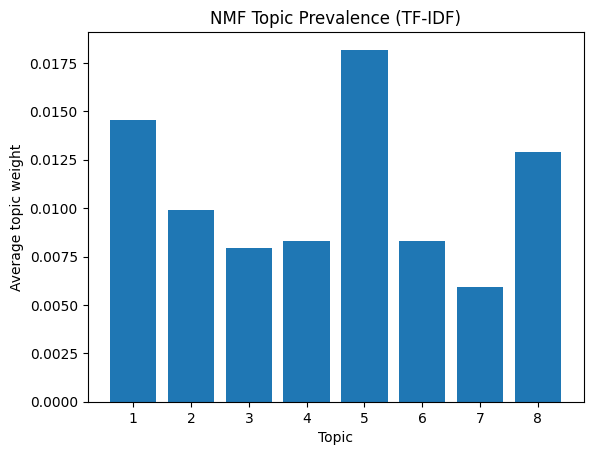

In [19]:
topic_prevalence_nmf = W.mean(axis=0)
top_topic_idx_nmf = int(topic_prevalence_nmf.argmax())

print("Most prevalent NMF topic:", top_topic_idx_nmf + 1)
print("Top words:", ", ".join(get_top_words(nmf, feature_names_tfidf, top_topic_idx_nmf)))

plt.figure()
plt.bar(range(1, len(topic_prevalence_nmf)+1), topic_prevalence_nmf)
plt.xlabel("Topic")
plt.ylabel("Average topic weight")
plt.title("NMF Topic Prevalence (TF-IDF)")
plt.show()


Most prevalent NMF topic: 5
Top words: product, amazon, price, great, find, order, store, buy, stores, time, local, shipping


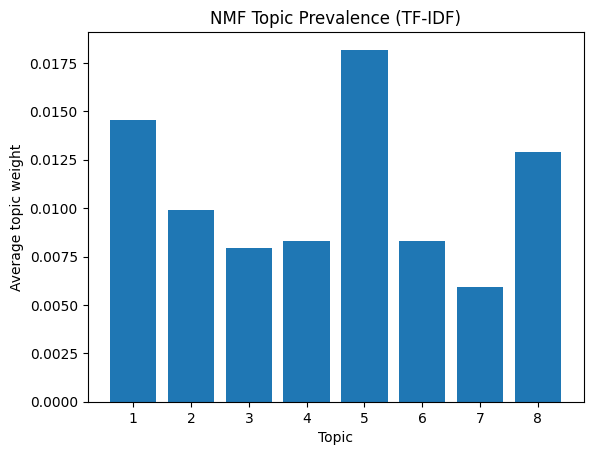

In [20]:
topic_prevalence_nmf = W.mean(axis=0)
top_topic_idx_nmf = int(topic_prevalence_nmf.argmax())

print("Most prevalent NMF topic:", top_topic_idx_nmf + 1)
print("Top words:", ", ".join(get_top_words(nmf, feature_names_tfidf, top_topic_idx_nmf)))

plt.figure()
plt.bar(range(1, len(topic_prevalence_nmf)+1), topic_prevalence_nmf)
plt.xlabel("Topic")
plt.ylabel("Average topic weight")
plt.title("NMF Topic Prevalence (TF-IDF)")
plt.show()
